<img src="https://radar.community.uaf.edu/wp-content/uploads/sites/667/2021/03/HydroSARbanner.jpg" width="100%" />

<br>
<font size="6"> <b>FIER Daily Flood Forecasting Code</b><img style="padding: 7px" src="https://radar.community.uaf.edu/wp-content/uploads/sites/667/2021/03/UAFLogo_A_647.png" width="170" align="right"/></font>

<br>
<font size="4"> <b> Franz J Meyer, University of Alaska Fairbanks</b> <br>
</font>

This notebook uses polynomial functions and neural network models to generate daily flood inundation predictions using time series of Sentinel-1 RTC data and GEOGLoWs river runoff forecasts. 
    
The workflow utilizes information available in the fierpy <a href="https://github.com/SERVIR/fierpy">fierpy</a> GitHub repository.
<hr>


# Load Python Libraries

In [5]:
# load needed modules
import _pickle as cPickle
from pathlib import Path
import time
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rasterio
from datetime import datetime

In [6]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.layers import Normalization
print(tf.__version__)

2024-11-12 23:47:06.405300: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-12 23:47:06.410056: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-12 23:47:06.427377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-12 23:47:06.456209: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-12 23:47:06.464922: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-12 23:47:06.485149: I tensorflow/core/platform/cpu_feature_gu

2.17.0


***
## Select working folder

In [7]:
from ipyfilechooser import FileChooser
fc = FileChooser(Path.cwd())
display(fc)

FileChooser(path='/home/jovyan/hydrosar', filename='', title='', show_hidden=False, select_desc='Select', chan…

***
## Load saved variables

In [8]:
# Load the variables
start_reload = time.time()


if 'modes_poly' in globals():
    del reof_ds, modes_poly, degs, polys, models_nn, modes_nn, q, q_tot, type_file, da_tot, ind_flood, floodpercent, time_flood
    print('Deleting old data...')
else:
    print('Loading data...')

with open(Path(fc.selected,"Forecasting-Files","Forecasting-Files.pkl"), "rb") as f:
    reof_ds = cPickle.load(f) # works
    print('reof_ds complete')
    modes_poly = cPickle.load(f) # works
    print('modes_poly complete')
    degs = cPickle.load(f) # works
    print('degs complete')
    polys = cPickle.load(f) # works
    print('polys complete')
    models_nn = cPickle.load(f) # works
    print('models_nn complete')
    modes_nn = cPickle.load(f) # works
    print('modes_nn complete')
    q = cPickle.load(f) # works
    print('q complete')
    q_tot = cPickle.load(f) # works
    print('q_tot complete')
    type_file = cPickle.load(f) # works
    print('type_file complete')
    da_tot = cPickle.load(f) # works
    print('da_tot complete')
    ind_flood = cPickle.load(f) # works
    print('ind_flood complete')
    floodpercent = cPickle.load(f) # works
    print('floodpercent complete')
    time_flood = cPickle.load(f) # works
    print('time_flood complete')
    lat = cPickle.load(f)
    lon = cPickle.load(f)
    print('lat & lon complete')
    ReachID = cPickle.load(f)
    print('ReachID complete')

end_reload = time.time()

print('It took ',end_reload-start_reload,' seconds to load the variables.')

Loading data...
reof_ds complete
modes_poly complete
degs complete
polys complete
models_nn complete
modes_nn complete
q complete
q_tot complete
type_file complete
da_tot complete
ind_flood complete
floodpercent complete
time_flood complete
lat & lon complete
ReachID complete
It took  1.058427095413208  seconds to load the variables.


In [9]:
modes_poly

[1, 4, 7, 8]

In [10]:
modes_nn

[1, 4, 8]

## Define important functions

In [11]:
### --- Z-Score calculation --- ###
def z_score(flood_forecast, flood_hindcast):
    # Calculate the indices for scoring: a = true positive, b = false positive, c = false negative, d = true negative
    a = np.sum(np.logical_and(flood_forecast == 1, flood_hindcast == 1))
    b = np.sum(np.logical_and(flood_forecast == 1, flood_hindcast == 0))
    c = np.sum(np.logical_and(flood_forecast == 0, flood_hindcast == 1))
    d = np.sum(np.logical_and(flood_forecast == 0, flood_hindcast == 0))

    # Calculate the skills
    overall_accuracy = ((a + b) / (a + b + c + d)) * 100
    CSI = (a / (a + b + c)) * 100
    precision = (a / (a + b)) * 100
    recall = (a / (a + c)) * 100
    
    # Replace NaNs by 0s
    if np.isnan(overall_accuracy):
        overall_accuracy = 0
    if np.isnan(CSI):
        CSI = 0
    if np.isnan(precision):
        precision = 0
    if np.isnan(recall):
        recall = 0

    return overall_accuracy, CSI, precision, recall
    

***
## Run the forecast

In [12]:
# Code will assume that the forecast needs to predict from the day that it is run onward. 

In [38]:
!pip install --upgrade xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2024.2.0
    Uninstalling xarray-2024.2.0:
      Successfully uninstalled xarray-2024.2.0

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [41]:
from geoglows import streams, data
ds4 = data.forecast(ReachID, format='xarray')
ds4

<xarray.Dataset> Size: 3kB
Dimensions:                 (time: 120)
Coordinates:
  * time                    (time) object 960B 1731369600000000000 ... 173265...
Data variables:
    flow_uncertainty_upper  (time) float64 960B 1.94 1.64 1.52 ... 1.35 1.34
    flow_median             (time) float32 480B 1.94 1.64 1.5 ... 1.28 1.27 1.27
    flow_uncertainty_lower  (time) float64 960B 1.94 1.64 1.49 ... 1.2 1.2 1.2
Attributes:
    source:          geoglows
    forecast_date:   20241112
    retrieval_date:  20241113
    units:           cubic meters per second

In [42]:
import pandas as pd
ds4 = ds4.assign_coords(time=pd.to_datetime(ds4.time.values))

In [43]:
ds4 = ds4.resample(time='1D').sum()

In [59]:
### --- Prepare Discharge dataset --- ###
# This will be replaced by code that automatically selects today's date and pulls the newest geoglows data. 

# Find the index of the first day of the forecast
ind_start = np.where(q_tot.time == q.time[-1])[0][0]

# Find the index of the last day of the forecast
ind_stop = np.where(q_tot.time == da_tot.time[ind_flood])[0][0]

# Crop the discharge to the same range as the forecast
q_forecast = q_tot.isel(time=slice(ind_start, ind_stop + 1))
q_forecast


<xarray.DataArray 'discharge' (time: 13)> Size: 52B
array([ 1.0814596,  1.0712521,  3.325644 ,  7.59001  , 11.415583 ,
       12.316677 ,  6.5265927,  3.289177 ,  3.0471804,  8.931731 ,
        8.207296 ,  4.1640387,  4.1419826], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 104B 2023-08-03 2023-08-04 ... 2023-08-15

In [62]:
q_forecast = ds4['flow_median'].rename('discharge')

In [63]:
q_forecast.shape

(15,)

In [64]:
q_forecast

<xarray.DataArray 'discharge' (time: 15)> Size: 60B
array([13.889999, 15.139999, 14.85    , 14.41    , 13.94    , 13.52    ,
       13.110001, 12.700001, 12.32    , 11.950001, 11.6     , 11.24    ,
       10.92    , 10.59    , 10.289999], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 120B 2024-11-12 2024-11-13 ... 2024-11-26

In [51]:
# define function to create the forecast for a single mode

def mySingleModeForecaster(forecastType, allModes, myMode, q_forecast, reof_ds, models, type_file): 
    # Create the forecast based on a single spatial mode

    # Get dimensions of datasets
    n_modes, y, x = reof_ds.spatial_modes.shape
    t = q_forecast.shape[0]

    # Create the variable filled with zeros
    zeros_variable = np.zeros((t, y, x))

    ### --- Initialize some important arrays --- ###
    
    # Create the new DataArray with zeros_variable
    da = xr.DataArray(
        zeros_variable,
        coords={'time': q_forecast.time, 'y': reof_ds.y, 'x': reof_ds.x},
        dims=['time', 'y', 'x']
    )

    # Make predictions using the best model(s)
    if 'p' in forecastType:
        print('poly ran')
        forecast_rtcp = np.array([model(q_forecast.values) for model in models]).squeeze()
    elif 'n' in forecastType:
        print('neural ran')
        forecast_rtcp = np.array([model.predict(q_forecast.values) for model in models]).squeeze() # original
    else:
        print('Input forecastType is neither neural network nor polynomial!')

    # Check the size of the forecasted rtcps. If it has only one dimension, add a new dimension
    if len(forecast_rtcp.shape) == 1:
        print('this ran')
        forecast_rtcp = forecast_rtcp[:, np.newaxis] # Add a new dimension
        forecast_rtcp = forecast_rtcp.T # Transpose to match the dimensions of the spatial modes

    ### --- Reconstruct the dataset by multiplying the spatial mode by the forecast for each significant mode --- ###
    
    idxM = allModes.index(myMode)
    forecast_nocenter = np.dot(reof_ds.spatial_modes.sel(mode=allModes[idxM]).values.reshape(-1,1), forecast_rtcp[idxM].reshape(1,len(forecast_rtcp[idxM]))).reshape(y,x,t).transpose(2,0,1)
    for i in range(0,forecast_nocenter.shape[0]):
        forecast_nocenter[i,:,:] = np.flipud(forecast_nocenter[i,:,:])
    

    # Add to the reconstructed dataset
    da.values += forecast_nocenter + reof_ds.center.values

    # If water mask, REOF gives FLOAT we have to round to 0 or 1
    if type_file == 'Water_Masks':
        da.values = np.round(da.values)

    # Convert 255 to NaN
    da.values = np.where(da.values==255, np.nan, da.values)
    
    return da

In [52]:
modes_nn

[1, 4, 8]

In [53]:
modes_poly

[1, 4, 7, 8]

In [65]:
### --- Run forecast on a single mode --- ###
myMode_nn = 1
if modes_nn != []:
    da_nn = mySingleModeForecaster('neural network',modes_nn, myMode_nn, q_forecast, reof_ds, models_nn, type_file)

neural ran
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [66]:
da_nn.shape

(15, 3901, 1209)

In [67]:

myMode_poly = 1
if modes_poly != []:
    da_poly = mySingleModeForecaster('polynomial', modes_poly, myMode_poly, q_forecast, reof_ds, polys, type_file)

poly ran


In [68]:
da_poly.shape

(15, 3901, 1209)

In [69]:
unique_elements, counts = np.unique(da_nn[-1,:,:], return_counts=True)
print(unique_elements)
print(counts)

[ 0.  1. nan]
[1059454 1329009 2327846]


In [70]:
unique_elements, counts = np.unique(da_poly[-1,:,:], return_counts=True)
print(unique_elements)
print(counts)

[ 0.  1. nan]
[1195069 1193394 2327846]


***
# Multi-mode Forecast

This code is in progress. It runs, but the resultant forecasts are not as good as the single mode forecast. 

In [71]:
### --- Run forecast on all of the best modes and sum them --- ###

# Get dimensions of datasets
n_modes, y, x = reof_ds.spatial_modes.shape
t = q_forecast.shape[0]

# Create the variable filled with zeros
zeros_variable = np.zeros((t, y, x))

### --- Initialize some important arrays --- ###

# Create the new DataArray with zeros_variable
da_nn_aggregate = xr.DataArray(
    zeros_variable,
    coords={'time': q_forecast.time, 'y': reof_ds.y, 'x': reof_ds.x},
    dims=['time', 'y', 'x']
)
da_poly_aggregate = xr.DataArray(
    zeros_variable,
    coords={'time': q_forecast.time, 'y': reof_ds.y, 'x': reof_ds.x},
    dims=['time', 'y', 'x']
)

type_file_sum = 'none' # making it anything other than 'Water_Masks' prevents the rounding from running, which we need to do after we've summed everything up. 



In [72]:
# Run forecast for the neural network
if modes_nn != []:
    for mode in modes_nn:
        da_nn_loop = mySingleModeForecaster('neural network',modes_nn, mode, q_forecast, reof_ds, models_nn, type_file_sum) # calculate the forecast for an individual mode
        da_nn_aggregate.values = da_nn_aggregate.values + da_nn_loop.values # collect all of the forecasts
    da_nn_aggregate.values = np.round(da_nn_aggregate.values) # round the values since it's either water (>0.5) or it isn't (<0.5)
    idx = (da_nn_aggregate >= 0.5) * (da_nn_aggregate < 255)
    da_nn_aggregate.values[idx] = 1.0
    idx = (da_nn_aggregate >= 255)
    da_nn_aggregate.values[idx] = 255
    # Convert 255 to NaN
    da_nn_aggregate.values = np.where(da_nn_aggregate.values==255, np.nan, da_nn_aggregate.values)


neural ran
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
neural ran
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
neural ran
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [73]:
# Run forecast for the polynomials
if modes_poly != []:
    for mode in modes_poly:
        da_poly_loop = mySingleModeForecaster('polynomial', modes_poly, mode, q_forecast, reof_ds, polys, type_file_sum)
        da_poly_aggregate.values = da_poly_aggregate.values + da_poly_loop.values
    da_poly_aggregate.values = np.round(da_poly_aggregate.values)
    idx = (da_poly_aggregate >= 0.5) * (da_poly_aggregate < 255)
    da_poly_aggregate.values[idx] = 1.0
    idx = (da_poly_aggregate >= 255)
    da_poly_aggregate.values[idx] = 255
    # Convert 255 to NaN
    da_poly_aggregate.values = np.where(da_poly_aggregate.values==255, np.nan, da_poly_aggregate.values)


poly ran
poly ran
poly ran
poly ran


In [74]:
unique_elements, counts = np.unique(da_nn_aggregate[-1,:,:], return_counts=True)
print(unique_elements)
print(counts)

[ 0.  1. nan]
[ 996093 1392370 2327846]


In [75]:
unique_elements, counts = np.unique(da_poly_aggregate[-1,:,:], return_counts=True)
print(unique_elements)
print(counts)

[ 0.  1. nan]
[1059331 1329132 2327846]


***
## Accuracy of forecasts

Compare the forecast results to actual flood extent or SAR imagery. 

NN Overall accuracy: 55.64%
NN Critical Success Index: 54.02%
NN Precision: 56.53%
NN Recall: 92.40%
Polynomial Overall accuracy: 49.96%
Polynomial Critical Success Index: 58.01%
Polynomial Precision: 61.73%
Polynomial Recall: 90.59%


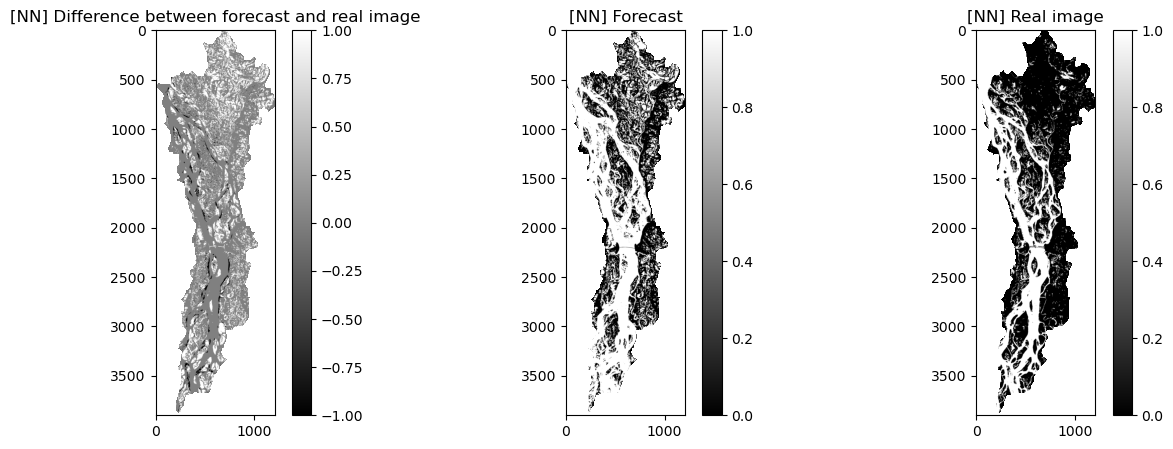

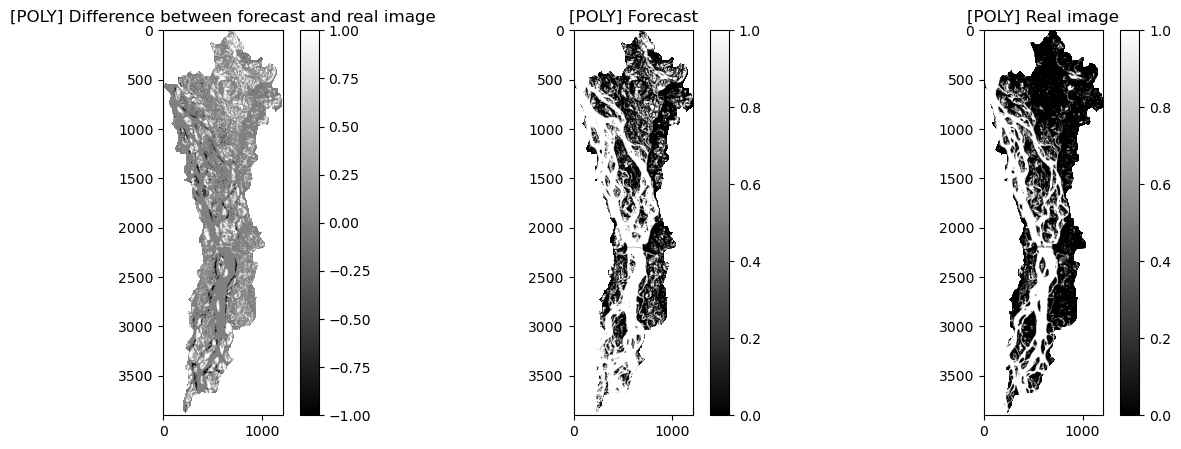

In [76]:
myCmap = 'gray'

### --- Calculate the scores of the forecasts --- ###
if modes_nn != []:
    overall_accuracy, CSI, precision, recall = z_score(da_nn.values[-1], da_tot.values[ind_flood])
    print(f"NN Overall accuracy: {overall_accuracy:.2f}%")
    print(f"NN Critical Success Index: {CSI:.2f}%")
    print(f"NN Precision: {precision:.2f}%")
    print(f"NN Recall: {recall:.2f}%")

    ### --- Plot the forecasts --- ###

    ## Neural Net
    # Plot the forecast - the real image
    fig_nn_results, ax_nn_results = plt.subplots(1,3,figsize=(15,5))
    im = ax_nn_results[0].imshow(da_nn.values[-1] - da_tot.values[ind_flood], vmin=-1, vmax=1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[0])
    ax_nn_results[0].set_title('[NN] Difference between forecast and real image')

    # Plot the forecast
    im = ax_nn_results[1].imshow(da_nn.values[-1], vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[1])
    ax_nn_results[1].set_title('[NN] Forecast')

    # Plot the real image
    im = ax_nn_results[2].imshow(da_tot.values[ind_flood], vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[2])
    ax_nn_results[2].set_title('[NN] Real image')

    

if modes_poly != []:
    overall_accuracy, CSI, precision, recall = z_score(da_poly.values[-1], da_tot.values[ind_flood])
    print(f"Polynomial Overall accuracy: {overall_accuracy:.2f}%")
    print(f"Polynomial Critical Success Index: {CSI:.2f}%")
    print(f"Polynomial Precision: {precision:.2f}%")
    print(f"Polynomial Recall: {recall:.2f}%")

    ### --- Plot the forecasts --- ###

    # Plot the forecast - the real image
    fig_poly_results, ax_poly_results = plt.subplots(1,3,figsize=(15,5))
    im = ax_poly_results[0].imshow(np.round(da_poly.values[-1] - da_tot.values[ind_flood]), vmin=-1, vmax=1, cmap=myCmap)
    plt.colorbar(im, ax=ax_poly_results[0])
    ax_poly_results[0].set_title('[POLY] Difference between forecast and real image')


    # Plot the forecast
    im = ax_poly_results[1].imshow(np.round(da_poly.values[-1]), vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax = ax_poly_results[1])
    ax_poly_results[1].set_title('[POLY] Forecast')

    # Plot the real image
    im = ax_poly_results[2].imshow(np.round(da_tot.values[ind_flood]), vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_poly_results[2])
    ax_poly_results[2].set_title('[POLY] Real image')

NN Overall accuracy: 58.30%
NN Critical Success Index: 55.40%
NN Precision: 56.47%
NN Recall: 96.70%
Polynomial Overall accuracy: 55.65%
Polynomial Critical Success Index: 58.38%
Polynomial Precision: 59.41%
Polynomial Recall: 97.11%


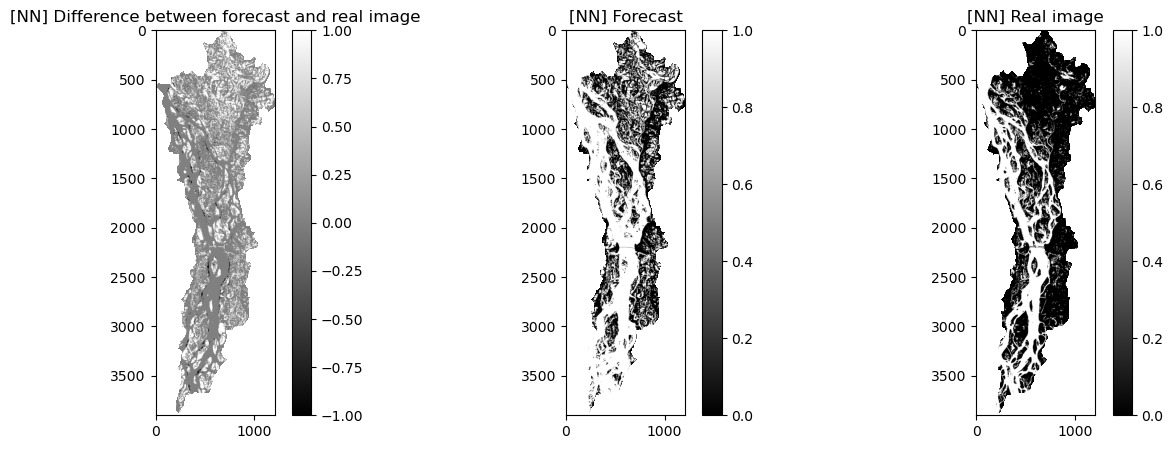

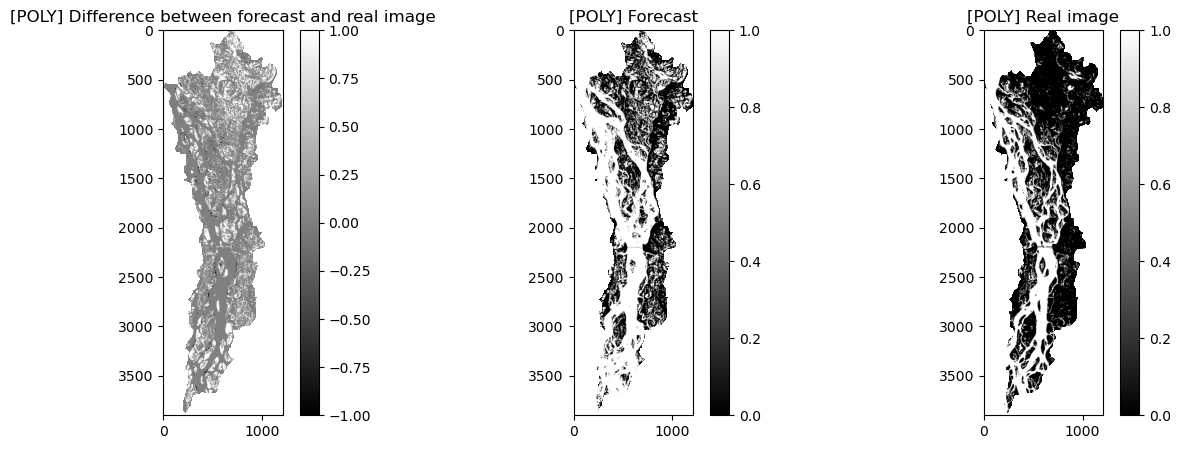

In [77]:
myCmap = 'gray'

# Multi-mode plot

### --- Calculate the scores of the forecasts --- ###
if modes_nn != []:
    overall_accuracy, CSI, precision, recall = z_score(da_nn_aggregate.values[-1], da_tot.values[ind_flood])
    print(f"NN Overall accuracy: {overall_accuracy:.2f}%")
    print(f"NN Critical Success Index: {CSI:.2f}%")
    print(f"NN Precision: {precision:.2f}%")
    print(f"NN Recall: {recall:.2f}%")

    ### --- Plot the forecasts --- ###

    ## Neural Net
    # Plot the forecast - the real image
    fig_nn_results, ax_nn_results = plt.subplots(1,3,figsize=(15,5))
    im = ax_nn_results[0].imshow(da_nn_aggregate.values[-1] - da_tot.values[ind_flood], vmin=-1, vmax=1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[0])
    ax_nn_results[0].set_title('[NN] Difference between forecast and real image')

    # Plot the forecast
    im = ax_nn_results[1].imshow(da_nn_aggregate.values[-1], vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[1])
    ax_nn_results[1].set_title('[NN] Forecast')

    # Plot the real image
    im = ax_nn_results[2].imshow(da_tot.values[ind_flood], vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[2])
    ax_nn_results[2].set_title('[NN] Real image')

    

if modes_poly != []:
    overall_accuracy, CSI, precision, recall = z_score(da_poly_aggregate.values[-1], da_tot.values[ind_flood])
    print(f"Polynomial Overall accuracy: {overall_accuracy:.2f}%")
    print(f"Polynomial Critical Success Index: {CSI:.2f}%")
    print(f"Polynomial Precision: {precision:.2f}%")
    print(f"Polynomial Recall: {recall:.2f}%")

    ### --- Plot the forecasts --- ###

    # Plot the forecast - the real image
    fig_poly_results, ax_poly_results = plt.subplots(1,3,figsize=(15,5))
    im = ax_poly_results[0].imshow(np.round(da_poly_aggregate.values[-1] - da_tot.values[ind_flood]), vmin=-1, vmax=1, cmap=myCmap)
    plt.colorbar(im, ax=ax_poly_results[0])
    ax_poly_results[0].set_title('[POLY] Difference between forecast and real image')


    # Plot the forecast
    im = ax_poly_results[1].imshow(np.round(da_poly_aggregate.values[-1]), vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax = ax_poly_results[1])
    ax_poly_results[1].set_title('[POLY] Forecast')

    # Plot the real image
    im = ax_poly_results[2].imshow(np.round(da_tot.values[ind_flood]), vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_poly_results[2])
    ax_poly_results[2].set_title('[POLY] Real image')

***
### Plot of flood forecasts, flood percentages through time, and discharge through time

In [93]:
# define function to plot flood forecasts
def create_subplots(myArray,figsize):

    ncols, nrows = 5,3
    
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axs = axs.flatten()

    n_plots = myArray.shape[0]

    for i in range(0,n_plots):
        
        axs[i].imshow(myArray[i,:,:], cmap='gray', vmin=0.0, vmax=1.0)
        axs[i].title.set_text(f'{myArray[i].time.dt.strftime("%Y-%m-%d").values}')

    return

In [79]:
# define function to get flood percentages from each flood forecast. 

def floodPercentCalc(forecast): 
    # set up empty array into which to put the percentages
    floodPercent=np.array([])
    # set up the total number of forecasts and a counter to keep track of progress. 
    total = forecast.shape[0]
    county = 0
    print("Starting calcualtion")
    for cast in forecast:
        # get the unique elements and their counts
        unique_elements, counts = np.unique(cast, return_counts=True)
        myDict = dict(zip(unique_elements, counts))
        myArea = myDict[0] + myDict[1]
        flooded = myDict[1]
        floodPercent = np.append(floodPercent, flooded/myArea*100.0)
        county += 1
        print(f"{county} of {total} complete")
    return floodPercent

In [80]:
# define function to plot flood percentage and discharge through time

def plot_flood_and_discharge(forecasts,flood_percents,q_tot, floodpercent_real = [], time_real= []):
    
    # set up figure and twin the axis
    fig_perc_dis, ax1 = plt.subplots(figsize=(9,6))
    ax2 = ax1.twinx()
    
    # plot the neural network flood percentages
    ln1 = ax1.plot(forecasts.time, flood_percents, color='blue', marker='o', label='Predicted Flood Percentage')
    ax1.set_ylabel('Flood Percentage [%]')
    ax1.grid()
    
    # plot the discharge values through same time. 
    idx1, idx2 = np.where(forecasts[0].time == q_tot.time)[0][0], np.where(forecasts[-1].time == q_tot.time)[0][0]
    ln2 = ax2.plot(q_tot[idx1:idx2+1].time, q_tot[idx1:idx2+1], color='red', marker='^', label='Discharge')
    ax2.set_ylabel('Discharge [$m^3/s$]')

    if floodpercent_real.any():
        print('I ran!')
        # I AM HERE
        # find index for relevant times
        # idxA, idxB = np.where(time_real
    
        # add points of relevant times to ax1
    
    # create legend entries
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs)
    
    plt.show()

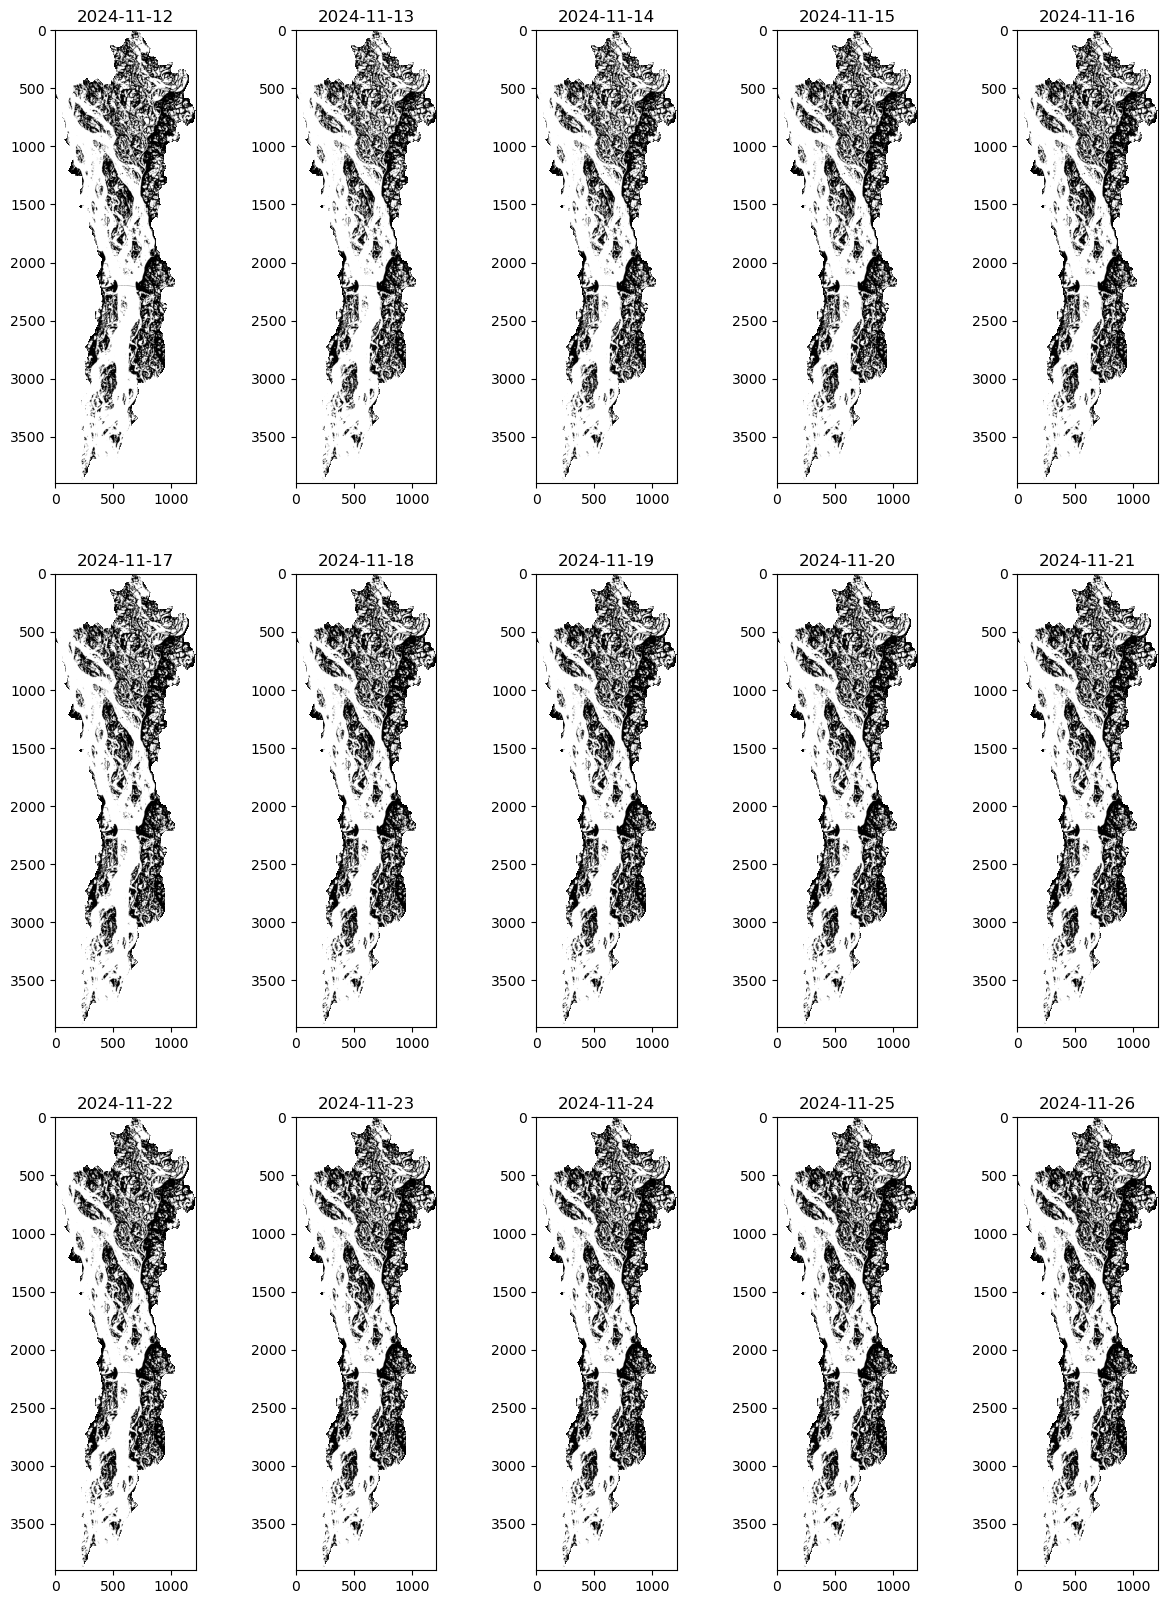

In [94]:
# plot each forecast day for neural network
create_subplots(da_nn_aggregate,(15,20))

In [95]:
flood_percent_nn = floodPercentCalc(da_nn_aggregate)
flood_percent_nn

Starting calcualtion
1 of 15 complete
2 of 15 complete
3 of 15 complete
4 of 15 complete
5 of 15 complete
6 of 15 complete
7 of 15 complete
8 of 15 complete
9 of 15 complete
10 of 15 complete
11 of 15 complete
12 of 15 complete
13 of 15 complete
14 of 15 complete
15 of 15 complete


array([60.55727051, 62.76207754, 62.49927254, 60.93349573, 60.55547019,
       60.50418198, 59.5785658 , 59.54796034, 59.48113913, 59.40330665,
       59.33422456, 59.23616987, 58.83201875, 58.41698197, 58.29564871])

I ran!


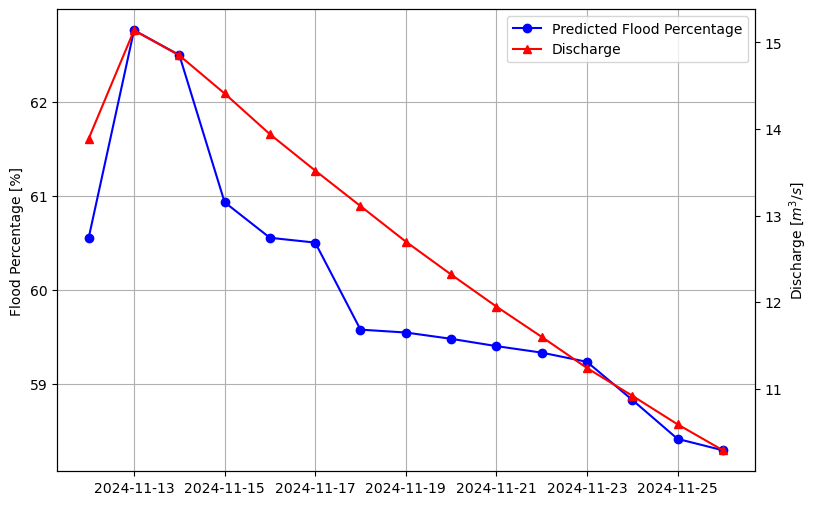

In [96]:
plot_flood_and_discharge(da_nn_aggregate,flood_percent_nn,q_forecast,floodpercent, time_flood)

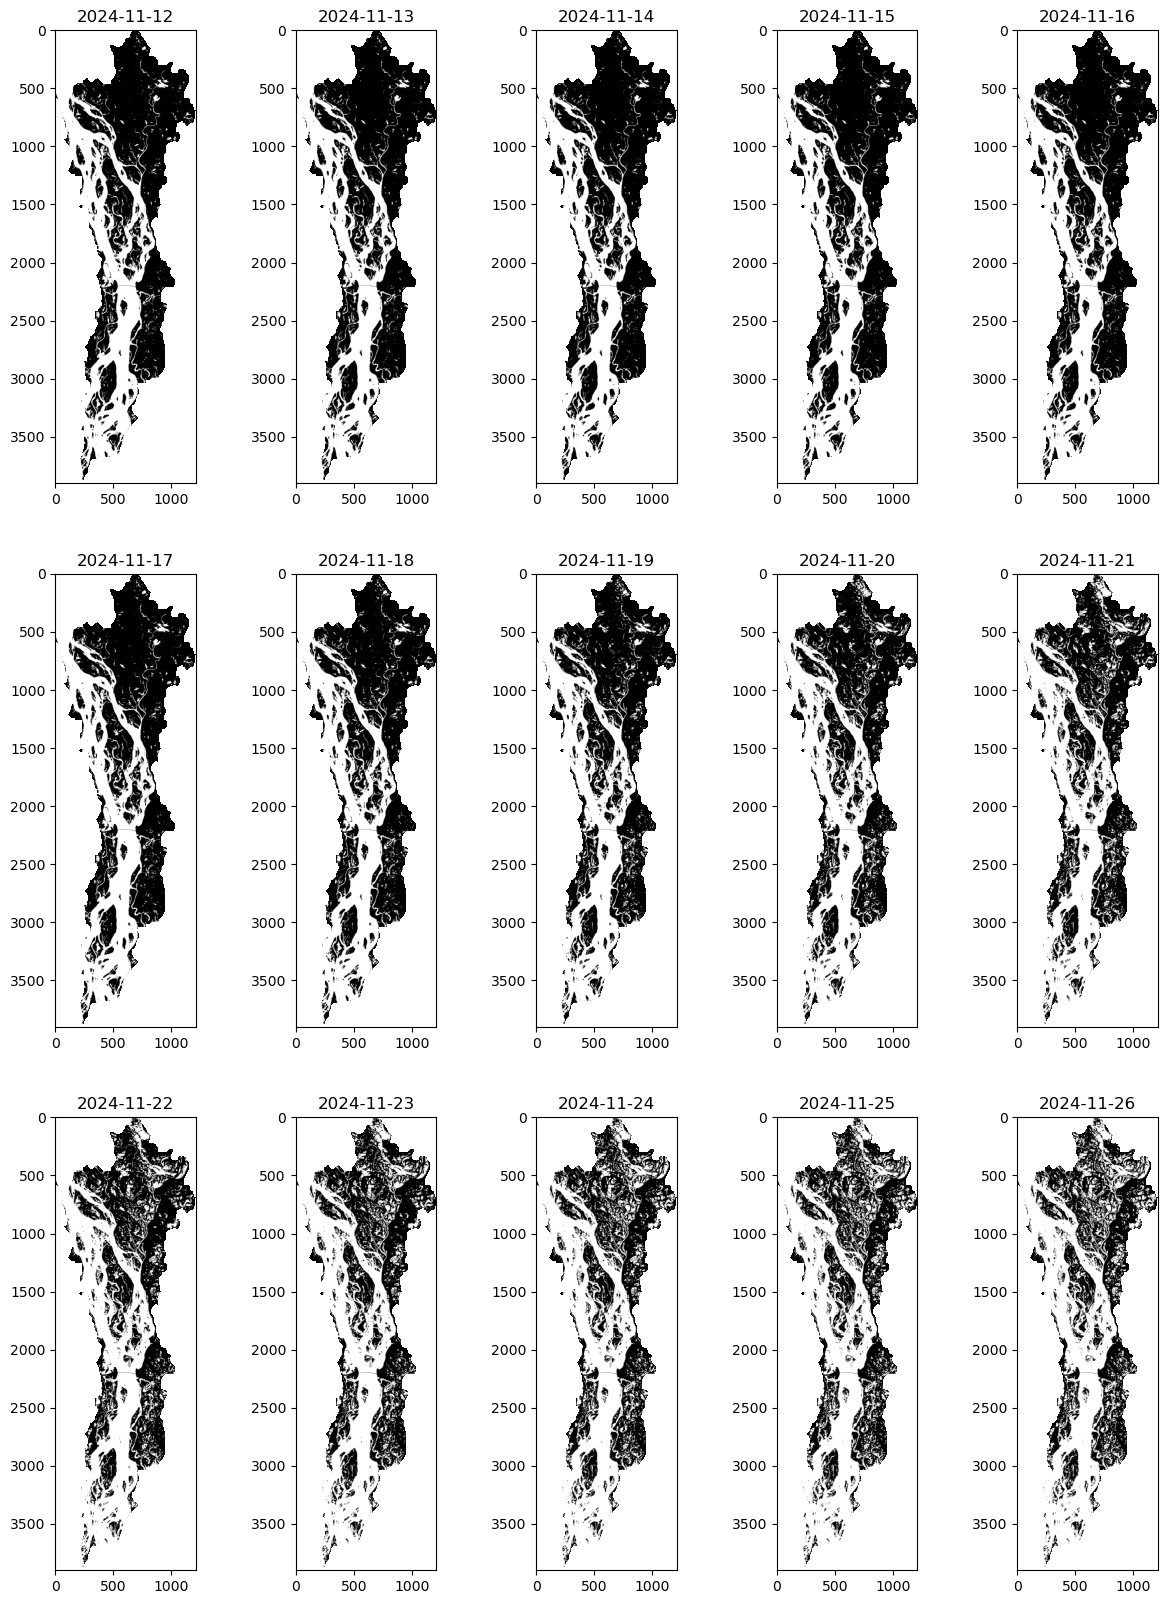

In [97]:
# plot each forecast day for neural network
create_subplots(da_poly_aggregate,(15,20))

In [98]:
flood_percent_poly = floodPercentCalc(da_poly_aggregate)

Starting calcualtion
1 of 15 complete
2 of 15 complete
3 of 15 complete
4 of 15 complete
5 of 15 complete
6 of 15 complete
7 of 15 complete
8 of 15 complete
9 of 15 complete
10 of 15 complete
11 of 15 complete
12 of 15 complete
13 of 15 complete
14 of 15 complete
15 of 15 complete


I ran!


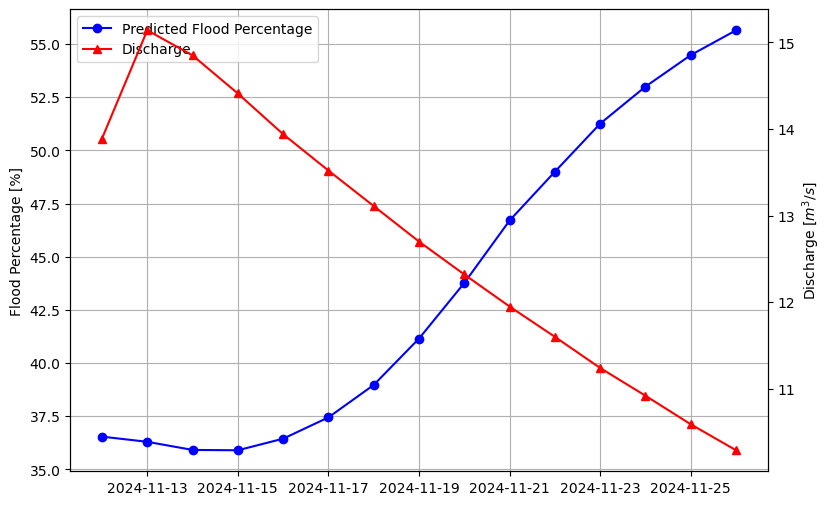

In [88]:
plot_flood_and_discharge(da_poly_aggregate,flood_percent_poly,q_forecast, floodpercent, time_flood)

***
## Save the data files of interest for later loading. 

TO SAVE
* plotted forecasts
* polynomials
* NN
* REOF modes (temporal and spatial)

In [34]:
# I AM HERE; need to improve this; what if they don't have water masks? 
# Load one of the SAR images or water masks in order to get the coordinate reference system. This is used in saving the forecasts as geotiffs. 
folder = fc.selected+'Water_Masks/'
prefix = '*combined'

# Gather names of files corresponding to the file type and polarization we want
tiff_dir = Path(folder)
tiffs = list(tiff_dir.glob(f'{prefix}.tif*'))

raster = rasterio.open(tiffs[0])

raster.crs

CRS.from_epsg(32646)

In [46]:
# Write function to save the forecasts as geotiffs. 
def saveForecasts(saveFolder, myRegion, da, raster, parent, theType):
    # Make directory if needed
    Path(parent, saveFolder).mkdir(parents=True, exist_ok=True)
    file2save_full = []
    
    county = 1
    for tiff in da:
        # flip the data; it looks upside here, but it saves and displays incorrectly in ArcGIS without it
        # myValues = np.abs(np.flipud(tiff.values))
        myValues = np.abs(tiff.values) # need to take the absolute value as there are some "negative" zero values (I know, negative zero isn't actually a thing; the computer sure thinks it is)
        # create save file name
        file2save = Path(parent,saveFolder,f'Region-{myRegion}_Day-{county:02d}_{str(tiff.time.dt.strftime("%Y-%m-%d").values)}_Created_{datetime.today().strftime('%Y-%m-%d')}_{theType}.tif')
        file2save_full.append(file2save)
        print(file2save)
        # open raster file and save
        with rasterio.open(
            file2save,
            mode="w",
            driver="GTiff",
            height=tiff.shape[0],
            width=tiff.shape[1],
            count=1,
            dtype=tiff.dtype,
            crs=raster.crs,
            transform=raster.transform,
        ) as new_dataset:
            new_dataset.write(myValues, 1)
        county += 1

    return file2save_full
    

In [47]:
# Save files
myRegion = f'lat-{lat:.2f}_lon-{lon:.2f}'
myRegion = f'ReachID-{ReachID}'
if type_file == 'Water_Masks':
    myType = 'WM'
else:
    myType = 'RTC'

save_folder = 'forecasts-poly'
flnms_nn = saveForecasts(save_folder, myRegion, da_poly, raster, fc.selected, myType)
save_folder = 'forecasts-nn'
flnms_poly = saveForecasts(save_folder, myRegion, da_nn, raster, fc.selected, myType)

/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-01_2023-08-03_Created_2024-11-12_WM.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-02_2023-08-04_Created_2024-11-12_WM.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-03_2023-08-05_Created_2024-11-12_WM.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-04_2023-08-06_Created_2024-11-12_WM.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-05_2023-08-07_Created_2024-11-12_WM.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-06_2023-08-08_Created_2024-11-12_WM.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-07_2023-08-

In [48]:
flnms_nn

[PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-01_2023-08-03_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-02_2023-08-04_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-03_2023-08-05_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-04_2023-08-06_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-05_2023-08-07_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-poly/Region-lat-24.47_lon-89.77_Day-06_2023-08-08_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hyd

In [49]:
flnms_poly

[PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-nn/Region-lat-24.47_lon-89.77_Day-01_2023-08-03_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-nn/Region-lat-24.47_lon-89.77_Day-02_2023-08-04_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-nn/Region-lat-24.47_lon-89.77_Day-03_2023-08-05_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-nn/Region-lat-24.47_lon-89.77_Day-04_2023-08-06_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-nn/Region-lat-24.47_lon-89.77_Day-05_2023-08-07_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts-nn/Region-lat-24.47_lon-89.77_Day-06_2023-08-08_Created_2024-11-12_WM.tif'),
 PosixPath('/home/jovyan/hydrosar/Datase

# Save to S3 bucket

In [44]:
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 138.6 MB/s eta 0:00:00
  Attempting uninstall: botocore
    Found existing installation: botocore 1.35.23
    Uninstalling botocore-1.35.23:
      Successfully uninstalled botocore-1.35.23
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.15.1 requires botocore<1.35.24,>=1.35.16, but you have botocore 1.35.59 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [45]:
import boto3

In [ ]:
s3_nn = boto3.client('s3')
for flnm in flnms_nn: 
    myKey = 
    s3_nn.upload_file(Filename=flnm, Bucket='s3://hyp3-nasa-disasters', Key=[])